T3: TCN + BiLSTM PSG TEACHER
Device       : cuda
Architecture : TCN + BiLSTM
Input        : PSG F3 + C3 + EOG1
Context      : 7  Window: 15
Loss         : Weighted Cross-Entropy
Seeds        : [42, 123, 256, 789, 999]
Epochs       : 30  Batch size: 64
Output       : D:\22\AA\AA journal\evaluation\tcn_bilstm_c7_valfixed
GPU          : NVIDIA GeForce RTX 4090

Split loaded -> Train:65  Val:11  Test:20
Train subjects: ['sub-001', 'sub-002', 'sub-004', 'sub-008', 'sub-009', 'sub-010', 'sub-011', 'sub-012', 'sub-016', 'sub-020', 'sub-022', 'sub-024', 'sub-025', 'sub-027', 'sub-029', 'sub-031', 'sub-032', 'sub-033', 'sub-034', 'sub-039', 'sub-041', 'sub-043', 'sub-044', 'sub-046', 'sub-047', 'sub-048', 'sub-050', 'sub-054', 'sub-056', 'sub-059', 'sub-060', 'sub-062', 'sub-063', 'sub-066', 'sub-067', 'sub-070', 'sub-071', 'sub-072', 'sub-075', 'sub-079', 'sub-080', 'sub-082', 'sub-084', 'sub-085', 'sub-086', 'sub-088', 'sub-089', 'sub-090', 'sub-091', 'sub-092', 'sub-094', 'sub-095', 'sub-096

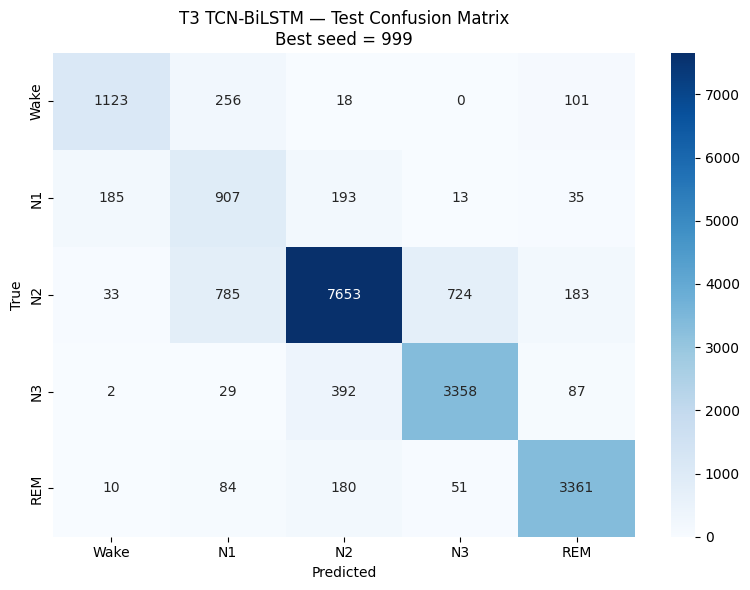

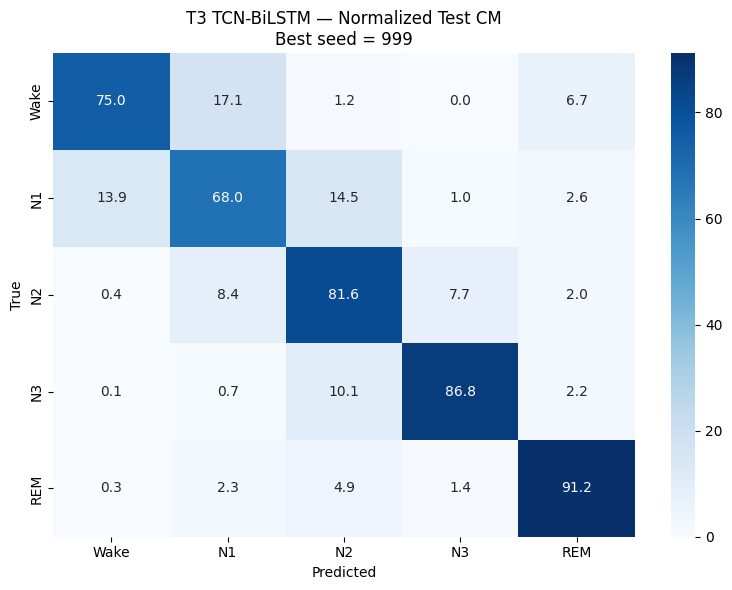

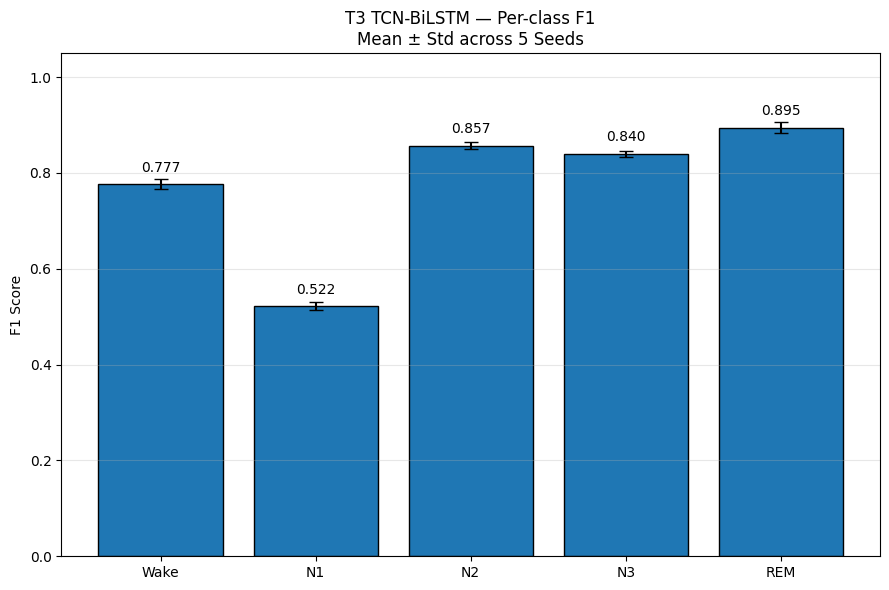

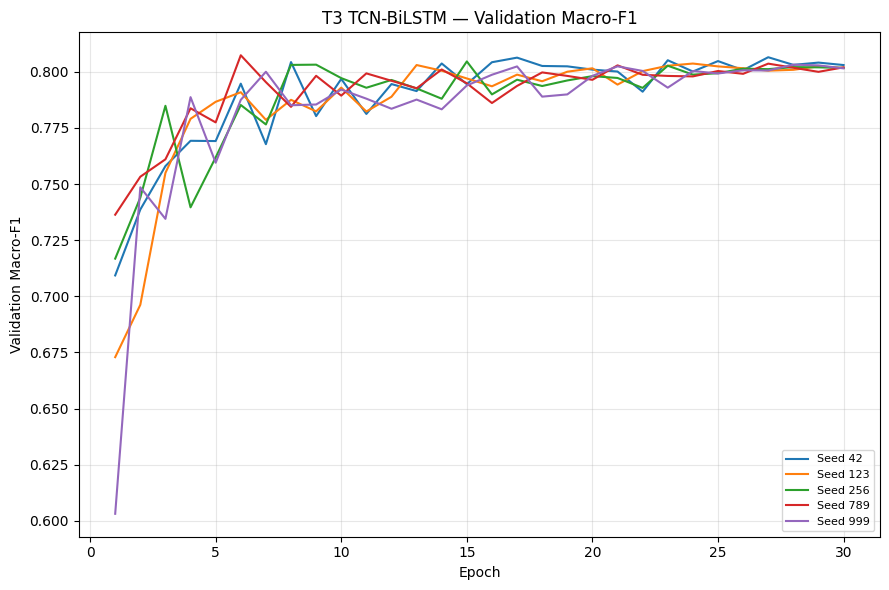


T3 EXPERIMENT COMPLETE

Final Accuracy : 82.37 ± 0.81%
Final Macro-F1 : 0.7780 ± 0.0076
Final Kappa    : 0.7523 ± 0.0104

Summary CSV:
D:\22\AA\AA journal\evaluation\tcn_bilstm_c7_valfixed\summary.csv

Epoch log:
D:\22\AA\AA journal\evaluation\tcn_bilstm_c7_valfixed\all_seeds_epoch_log.csv

Best seed: 999

All outputs saved to:
D:\22\AA\AA journal\evaluation\tcn_bilstm_c7_valfixed

DONE


In [1]:
# ============================================================
# T3: TCN + BiLSTM PSG TEACHER
#
# Context epochs (15) -> Per-epoch TCN -> Inter-epoch BiLSTM
#   -> Center epoch feature -> Classifier
#
# Loss = Weighted Cross-Entropy (NO SupCon, NO artifact weighting)
# Context = 7 -> Window = 15
# Seeds = 42, 123, 256, 789, 999
# ============================================================

import os
import csv
import math
import random
import warnings
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score, confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")


# ============================================================
# PATHS & CONFIG
# ============================================================

DATA_PATH = r"D:\22\AA\preprocess\preprocessed_FFinal"
SPLIT_PATH = r"D:\22\AA\AA journal\preprocess\preprocessed_split_v2"
EVAL_PATH = r"D:\22\AA\AA journal\evaluation\tcn_bilstm_c7_valfixed"

os.makedirs(EVAL_PATH, exist_ok=True)

LABEL_NAMES = ["Wake", "N1", "N2", "N3", "REM"]
N_CLASSES = 5

CONTEXT = 7
WINDOW = 2 * CONTEXT + 1        # 15
N_EPOCHS = 30
BATCH_SIZE = 64
SEEDS = [42, 123, 256, 789, 999]

IN_CHANNELS = 3         # F3, C3, EOG1
TCN_CHANNELS = 128
LSTM_HIDDEN = 64
LSTM_LAYERS = 2
DROPOUT = 0.4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 70)
print("T3: TCN + BiLSTM PSG TEACHER")
print("=" * 70)
print(f"Device       : {device}")
print(f"Architecture : TCN + BiLSTM")
print(f"Input        : PSG F3 + C3 + EOG1")
print(f"Context      : {CONTEXT}  Window: {WINDOW}")
print(f"Loss         : Weighted Cross-Entropy")
print(f"Seeds        : {SEEDS}")
print(f"Epochs       : {N_EPOCHS}  Batch size: {BATCH_SIZE}")
print(f"Output       : {EVAL_PATH}")
if torch.cuda.is_available():
    print(f"GPU          : {torch.cuda.get_device_name(0)}")


# ============================================================
# FIXED 3-WAY SUBJECT SPLIT
# ============================================================

_paths = {
    "train": os.path.join(SPLIT_PATH, "_train_subs.npy"),
    "val": os.path.join(SPLIT_PATH, "_val_subs.npy"),
    "test": os.path.join(SPLIT_PATH, "_test_subs.npy"),
}

for name, p in _paths.items():
    if not os.path.exists(p):
        raise FileNotFoundError(f"\n{os.path.basename(p)} not found!\nExpected location:\n{p}\n\nPlease check SPLIT_PATH.")

TRAIN_SUBS = np.load(_paths["train"], allow_pickle=True).tolist()
VAL_SUBS = np.load(_paths["val"], allow_pickle=True).tolist()
TEST_SUBS = np.load(_paths["test"], allow_pickle=True).tolist()

assert set(TRAIN_SUBS).isdisjoint(VAL_SUBS), "TRAIN/VAL subject overlap!"
assert set(TRAIN_SUBS).isdisjoint(TEST_SUBS), "TRAIN/TEST subject overlap!"
assert set(VAL_SUBS).isdisjoint(TEST_SUBS), "VAL/TEST subject overlap!"

print(f"\nSplit loaded -> Train:{len(TRAIN_SUBS)}  Val:{len(VAL_SUBS)}  Test:{len(TEST_SUBS)}")
print(f"Train subjects: {TRAIN_SUBS}")
print(f"Val subjects  : {VAL_SUBS}")
print(f"Test subjects : {TEST_SUBS}")


# ============================================================
# DATASET
# ============================================================

class PSGContextDataset(Dataset):
    def __init__(self, subject_list, data_path, context=CONTEXT):
        self.context = context
        self.data = []
        self.index = []

        label_counter = Counter()

        for sub in subject_list:
            fp = os.path.join(data_path, f"{sub}.npz")
            if not os.path.exists(fp):
                print(f"WARNING: Missing file: {fp}")
                continue

            with np.load(fp) as d:
                eeg = d["eeg"][:, [0, 1], :]        # F3, C3
                eog = d["eog"][:, [0], :]            # EOG1
                signal = np.concatenate([eeg, eog], axis=1).astype(np.float32)
                labels = d["labels"].copy()

            n = len(labels)
            sub_idx = len(self.data)
            self.data.append((signal, labels))

            for i in range(n):
                self.index.append((sub_idx, i, n))
                label_counter[int(labels[i])] += 1

        self.label_counts = np.array(
            [label_counter[i] for i in range(N_CLASSES)], dtype=np.float32
        )

        total = len(self.index)
        ram = sum(signal.nbytes for signal, _ in self.data) / 1e9

        print(f"  Subjects : {len(self.data)}")
        print(f"  Samples  : {total:,}")
        print(f"  RAM      : {ram:.2f} GB")
        print("  Class distribution:")
        for i, name in enumerate(LABEL_NAMES):
            print(f"    {name:5s}: {int(self.label_counts[i]):,}")

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        sub_idx, center_i, n = self.index[idx]
        signal, labels = self.data[sub_idx]

        # context window i-7 ... i ... i+7 (boundary epochs replicated)
        window_epochs = []
        for offset in range(-self.context, self.context + 1):
            epoch_idx = max(0, min(n - 1, center_i + offset))
            window_epochs.append(signal[epoch_idx])

        x = np.stack(window_epochs, axis=0)   # (15, 3, 3000)
        y = int(labels[center_i])

        return torch.from_numpy(x), torch.tensor(y, dtype=torch.long)


print("\n" + "=" * 70)
print("BUILDING DATASETS")
print("=" * 70)

print("\n[TRAIN]")
train_ds = PSGContextDataset(TRAIN_SUBS, DATA_PATH, CONTEXT)
print("\n[VAL]")
val_ds = PSGContextDataset(VAL_SUBS, DATA_PATH, CONTEXT)
test_ds = None

print("\n[TEST]")
print("Test dataset will be loaded only during final test evaluation.")

print("\nDatasets ready.")


# ============================================================
# CLASS WEIGHTS (train only)
# ============================================================

train_counts = train_ds.label_counts.copy()
class_weights_np = train_counts.sum() / (N_CLASSES * train_counts)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

print("\n" + "=" * 70)
print("CLASS WEIGHTS")
print("=" * 70)
for name, count, weight in zip(LABEL_NAMES, train_counts, class_weights_np):
    print(f"{name:5s} | count={int(count):8,d} | weight={weight:.4f}")


# ============================================================
# TCN BLOCK
# ============================================================

class TCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=7, dilation=1, dropout=0.4):
        super().__init__()
        padding = ((kernel_size - 1) * dilation) // 2   # causal-style same-length padding

        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, padding=padding, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, padding=padding, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.dropout = nn.Dropout(dropout)
        self.residual = (
            nn.Conv1d(in_channels, out_channels, kernel_size=1)
            if in_channels != out_channels else nn.Identity()
        )

    def forward(self, x):
        # x: (B, C, T)
        residual = self.residual(x)

        out = self.dropout(F.gelu(self.bn1(self.conv1(x))))
        out = self.dropout(F.gelu(self.bn2(self.conv2(out))))

        return out + residual


# ============================================================
# TCN + BiLSTM MODEL
# ============================================================

class TCNBiLSTM(nn.Module):
    def __init__(self, in_channels=IN_CHANNELS, tcn_channels=TCN_CHANNELS, lstm_hidden=LSTM_HIDDEN,
                 lstm_layers=LSTM_LAYERS, dropout=DROPOUT, n_classes=N_CLASSES, context=CONTEXT):
        super().__init__()
        self.context = context
        self.window = 2 * context + 1

        # Epoch-level TCN: (B*W, 3, 3000) -> (B*W, 128, reduced_T)
        self.tcn = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=25, stride=4, padding=12),
            nn.BatchNorm1d(32), nn.GELU(), nn.MaxPool1d(4, 4),

            TCNBlock(32, 64, kernel_size=7, dilation=1, dropout=dropout),
            TCNBlock(64, 64, kernel_size=7, dilation=2, dropout=dropout),
            TCNBlock(64, 128, kernel_size=7, dilation=4, dropout=dropout),
            TCNBlock(128, 128, kernel_size=7, dilation=8, dropout=dropout),

            nn.MaxPool1d(2, 2),
            nn.Dropout(dropout),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, 3000)
            self.tcn_seq_len = self.tcn(dummy).shape[-1]

        self.intra_pool = nn.AdaptiveAvgPool1d(1)          # (B*W, 128, T) -> (B*W, 128)
        self.feature_norm = nn.LayerNorm(tcn_channels)

        # Inter-epoch BiLSTM: (B, W, 128) -> (B, W, 2*hidden)
        self.inter_lstm = nn.LSTM(
            input_size=tcn_channels, hidden_size=lstm_hidden, num_layers=lstm_layers,
            batch_first=True, bidirectional=True,
            dropout=(dropout if lstm_layers > 1 else 0.0),
        )

        self.center_norm = nn.LayerNorm(2 * lstm_hidden)

        self.classifier = nn.Sequential(
            nn.LayerNorm(2 * lstm_hidden),
            nn.Linear(2 * lstm_hidden, 64), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        # x: (B, W, C, T), e.g. (64, 15, 3, 3000)
        B, W, C, T = x.shape

        feat = self.tcn(x.reshape(B * W, C, T))
        feat = self.feature_norm(self.intra_pool(feat).squeeze(-1))
        feat = feat.reshape(B, W, TCN_CHANNELS)

        lstm_out, _ = self.inter_lstm(feat)

        # center index = context (0 1 2 3 4 5 6 [7] 8 9 10 11 12 13 14)
        center_feat = self.center_norm(lstm_out[:, self.context, :])

        return self.classifier(center_feat)


# ============================================================
# PARAMETER COUNT TEST
# ============================================================

print("\n" + "=" * 70)
print("MODEL CHECK")
print("=" * 70)

test_model = TCNBiLSTM().to(device)
n_params = sum(p.numel() for p in test_model.parameters())
trainable_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)

print(f"Total parameters     : {n_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"TCN sequence length  : {test_model.tcn_seq_len}")

del test_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()


# ============================================================
# UTILITIES
# ============================================================

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


def train_one_epoch(model, loader, optimizer, scheduler, criterion):
    model.train()
    total_loss = 0.0
    preds, labels_all = [], []

    for batch_idx, (x, y) in enumerate(loader):
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds.extend(logits.argmax(dim=1).detach().cpu().numpy())
        labels_all.extend(y.detach().cpu().numpy())

        if (batch_idx + 1) % 20 == 0:
            print(f"  batch {batch_idx + 1}/{len(loader)}", end="\r")

    preds, labels_all = np.array(preds), np.array(labels_all)
    acc = accuracy_score(labels_all, preds)
    f1 = f1_score(labels_all, preds, average="macro", zero_division=0)

    return total_loss / len(loader), acc, f1


def evaluate(model, loader):
    model.eval()
    preds, labels_all = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            pred = model(x).argmax(dim=1)
            preds.extend(pred.cpu().numpy())
            labels_all.extend(y.numpy())

    preds, labels_all = np.array(preds), np.array(labels_all)

    acc = accuracy_score(labels_all, preds)
    f1 = f1_score(labels_all, preds, average="macro", zero_division=0)
    kappa = cohen_kappa_score(labels_all, preds)
    per_class_f1 = f1_score(labels_all, preds, average=None, zero_division=0)
    cm = confusion_matrix(labels_all, preds, labels=np.arange(N_CLASSES))

    return acc, f1, kappa, per_class_f1, preds, labels_all, cm


def make_loaders(seed):
    # Windows + large in-RAM Dataset + multiple workers can duplicate RAM.
    # Keep num_workers=0 to avoid RAM duplication while retaining GPU training.
    # NOTE: test_loader is intentionally NOT built here — test_ds is only
    # populated later, per-seed, right before final test evaluation.
    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
        pin_memory=torch.cuda.is_available(),
        generator=torch.Generator().manual_seed(seed),
    )
    val_loader = DataLoader(
        val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    return train_loader, val_loader


# ============================================================
# CSV SETUP
# ============================================================

epoch_csv = os.path.join(EVAL_PATH, "all_seeds_epoch_log.csv")
summary_csv = os.path.join(EVAL_PATH, "summary.csv")

with open(epoch_csv, "w", newline="") as f:
    csv.writer(f).writerow([
        "seed", "epoch",
        "train_loss", "train_acc", "train_f1",
        "val_acc", "val_f1", "val_kappa",
        "lr",
    ])

SUMMARY_FIELDS = [
    "seed", "test_acc", "test_f1_macro", "test_kappa",
    "f1_Wake", "f1_N1", "f1_N2", "f1_N3", "f1_REM",
]

with open(summary_csv, "w", newline="") as f:
    csv.DictWriter(f, SUMMARY_FIELDS).writeheader()


# ============================================================
# 5-SEED TRAINING
# ============================================================

all_results = []
all_histories = []
all_cms = []

for seed_idx, seed in enumerate(SEEDS):
    print("\n" + "=" * 70)
    print(f"SEED {seed} ({seed_idx + 1}/{len(SEEDS)})")
    print("=" * 70)

    set_seed(seed)
    train_loader, val_loader = make_loaders(seed)

    model = TCNBiLSTM().to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"Parameters: {n_params:,}")

    # Only TRAIN class distribution used
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = optim.AdamW(
        model.parameters(), lr=5e-4, weight_decay=3e-4, betas=(0.9, 0.98), eps=1e-9
    )

    total_steps = N_EPOCHS * len(train_loader)
    warmup_steps = int(0.05 * total_steps)

    def lr_lambda(step, warmup_steps=warmup_steps, total_steps=total_steps):
        if step < warmup_steps:
            return step / max(warmup_steps, 1)
        progress = (step - warmup_steps) / max(total_steps - warmup_steps, 1)
        return 0.5 * (1 + math.cos(math.pi * progress))

    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

    best_val_f1, best_epoch = -1.0, 0
    best_path = os.path.join(EVAL_PATH, f"best_seed{seed}.pt")
    history = []

    for epoch in range(1, N_EPOCHS + 1):
        train_loss, train_acc, train_f1 = train_one_epoch(
            model, train_loader, optimizer, scheduler, criterion
        )

        # Validation only — test is NOT touched here
        val_acc, val_f1, val_kappa, val_per_class, _, _, _ = evaluate(model, val_loader)

        saved = ""
        if val_f1 > best_val_f1:
            best_val_f1, best_epoch = val_f1, epoch
            torch.save(model.state_dict(), best_path)
            saved = " <- BEST"

        lr = optimizer.param_groups[0]["lr"]

        history.append({
            "epoch": epoch, "train_loss": train_loss, "train_acc": train_acc, "train_f1": train_f1,
            "val_acc": val_acc, "val_f1": val_f1, "val_kappa": val_kappa, "lr": lr,
        })

        print(
            f"Ep[{epoch:02d}/{N_EPOCHS}] Loss:{train_loss:.4f} TrAcc:{train_acc:.4f} TrF1:{train_f1:.4f} "
            f"ValAcc:{val_acc:.4f} ValF1:{val_f1:.4f} K:{val_kappa:.4f} LR:{lr:.2e}{saved}"
        )

        if epoch % 10 == 0:
            print("  Val per-class F1: " + " | ".join(
                f"{LABEL_NAMES[i]}={val_per_class[i]:.4f}" for i in range(N_CLASSES)
            ))

        with open(epoch_csv, "a", newline="") as f:
            csv.writer(f).writerow([
                seed, epoch,
                f"{train_loss:.6f}", f"{train_acc:.6f}", f"{train_f1:.6f}",
                f"{val_acc:.6f}", f"{val_f1:.6f}", f"{val_kappa:.6f}",
                f"{lr:.8e}",
            ])

    print(f"\nBest validation F1: {best_val_f1:.4f}")
    print(f"Best epoch        : {best_epoch}")

    # ============================================================
    # LOAD TEST DATA ONLY FOR FINAL EVALUATION
    # ============================================================
    print("\nLoading TEST dataset for final evaluation...")
    test_ds = PSGContextDataset(TEST_SUBS, DATA_PATH, CONTEXT)

    test_loader = DataLoader(
        test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    # Load best validation checkpoint
    model.load_state_dict(torch.load(best_path, map_location=device))
    (test_acc, test_f1, test_kappa, test_per_class,
     test_preds, test_labels, test_cm) = evaluate(model, test_loader)

    all_cms.append(test_cm)

    print("\n" + "-" * 70)
    print(f"SEED {seed} FINAL TEST")
    print("-" * 70)
    print(f"Best Val Epoch : {best_epoch}")
    print(f"Test Accuracy  : {test_acc * 100:.2f}%")
    print(f"Test Macro F1  : {test_f1:.4f}")
    print(f"Test Kappa     : {test_kappa:.4f}")
    print("\nPer-class F1:")
    for i, name in enumerate(LABEL_NAMES):
        print(f"  {name:5s}: {test_per_class[i]:.4f}")

    result = {
        "seed": seed, "acc": test_acc, "f1": test_f1, "kappa": test_kappa,
        "per_class": test_per_class, "preds": test_preds, "labels": test_labels,
        "cm": test_cm, "best_epoch": best_epoch, "best_val_f1": best_val_f1,
    }
    all_results.append(result)
    all_histories.append(history)

    with open(summary_csv, "a", newline="") as f:
        csv.DictWriter(f, SUMMARY_FIELDS).writerow({
            "seed": seed,
            "test_acc": round(test_acc, 4), "test_f1_macro": round(test_f1, 4), "test_kappa": round(test_kappa, 4),
            "f1_Wake": round(test_per_class[0], 4), "f1_N1": round(test_per_class[1], 4),
            "f1_N2": round(test_per_class[2], 4), "f1_N3": round(test_per_class[3], 4),
            "f1_REM": round(test_per_class[4], 4),
        })

    # Release TEST RAM before the next seed.
    del test_loader
    del test_ds

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ============================================================
# FINAL 5-SEED REPORT
# ============================================================

print("\n" + "=" * 70)
print("T3: 5-SEED FINAL TEST REPORT")
print("=" * 70)

accs = np.array([r["acc"] for r in all_results]) * 100
f1s = np.array([r["f1"] for r in all_results])
kappas = np.array([r["kappa"] for r in all_results])

print(f"\n{'Seed':<8}{'Acc%':>10}{'MacroF1':>10}{'Kappa':>10}{'N1 F1':>10}")
print("-" * 55)
for r in all_results:
    print(f"{r['seed']:<8}{r['acc'] * 100:>10.2f}{r['f1']:>10.4f}{r['kappa']:>10.4f}{r['per_class'][1]:>10.4f}")
print("-" * 55)
print(f"{'Mean':<8}{accs.mean():>10.2f}{f1s.mean():>10.4f}{kappas.mean():>10.4f}"
      f"{np.mean([r['per_class'][1] for r in all_results]):>10.4f}")
print(f"{'Std':<8}{accs.std():>10.2f}{f1s.std():>10.4f}{kappas.std():>10.4f}"
      f"{np.std([r['per_class'][1] for r in all_results]):>10.4f}")

print("\n" + "=" * 70)
print("PAPER FORMAT")
print("=" * 70)
print(f"Accuracy : {accs.mean():.2f} ± {accs.std():.2f}%")
print(f"Macro F1 : {f1s.mean():.4f} ± {f1s.std():.4f}")
print(f"Kappa    : {kappas.mean():.4f} ± {kappas.std():.4f}")

print("\nPer-class F1:")
for i, name in enumerate(LABEL_NAMES):
    vals = np.array([r["per_class"][i] for r in all_results])
    print(f"  {name:5s}: {vals.mean():.4f} ± {vals.std():.4f}")

with open(summary_csv, "a", newline="") as f:
    writer = csv.DictWriter(f, SUMMARY_FIELDS)
    writer.writerow({
        "seed": "mean",
        "test_acc": round(accs.mean() / 100, 4), "test_f1_macro": round(f1s.mean(), 4),
        "test_kappa": round(kappas.mean(), 4),
        "f1_Wake": round(np.mean([r["per_class"][0] for r in all_results]), 4),
        "f1_N1": round(np.mean([r["per_class"][1] for r in all_results]), 4),
        "f1_N2": round(np.mean([r["per_class"][2] for r in all_results]), 4),
        "f1_N3": round(np.mean([r["per_class"][3] for r in all_results]), 4),
        "f1_REM": round(np.mean([r["per_class"][4] for r in all_results]), 4),
    })
    writer.writerow({
        "seed": "std",
        "test_acc": round(accs.std() / 100, 4), "test_f1_macro": round(f1s.std(), 4),
        "test_kappa": round(kappas.std(), 4),
        "f1_Wake": round(np.std([r["per_class"][0] for r in all_results]), 4),
        "f1_N1": round(np.std([r["per_class"][1] for r in all_results]), 4),
        "f1_N2": round(np.std([r["per_class"][2] for r in all_results]), 4),
        "f1_N3": round(np.std([r["per_class"][3] for r in all_results]), 4),
        "f1_REM": round(np.std([r["per_class"][4] for r in all_results]), 4),
    })


# ============================================================
# CONFUSION MATRIX — best seed = highest TEST Macro-F1
# ============================================================

best_result = max(all_results, key=lambda r: r["f1"])
best_seed = best_result["seed"]
cm = best_result["cm"]

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            cmap="Blues", cbar=True)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"T3 TCN-BiLSTM — Test Confusion Matrix\nBest seed = {best_seed}")
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "confusion_matrix_best_seed.png"), dpi=200)
plt.show()

cm_float = cm.astype(np.float64)
row_sums = cm_float.sum(axis=1, keepdims=True)
cm_pct = np.divide(cm_float, row_sums, out=np.zeros_like(cm_float), where=row_sums != 0) * 100

plt.figure(figsize=(8, 6))
sns.heatmap(cm_pct, annot=True, fmt=".1f", xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            cmap="Blues", cbar=True)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"T3 TCN-BiLSTM — Normalized Test CM\nBest seed = {best_seed}")
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "confusion_matrix_best_seed_normalized.png"), dpi=200)
plt.show()


# ============================================================
# PER-CLASS F1 PLOT
# ============================================================

per_class_means = np.array([
    np.mean([r["per_class"][i] for r in all_results]) for i in range(N_CLASSES)
])
per_class_stds = np.array([
    np.std([r["per_class"][i] for r in all_results]) for i in range(N_CLASSES)
])

plt.figure(figsize=(9, 6))
x = np.arange(N_CLASSES)
bars = plt.bar(x, per_class_means, yerr=per_class_stds, capsize=5, edgecolor="black")
plt.xticks(x, LABEL_NAMES)
plt.ylabel("F1 Score")
plt.ylim(0, 1.05)
plt.title("T3 TCN-BiLSTM — Per-class F1\nMean ± Std across 5 Seeds")
plt.grid(axis="y", alpha=0.3)

for bar, mean in zip(bars, per_class_means):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
              f"{mean:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "per_class_f1_5seed.png"), dpi=200)
plt.show()


# ============================================================
# TRAINING / VALIDATION CURVES
# ============================================================

plt.figure(figsize=(9, 6))
for history, seed in zip(all_histories, SEEDS):
    epochs = [h["epoch"] for h in history]
    val_f1_values = [h["val_f1"] for h in history]
    plt.plot(epochs, val_f1_values, linewidth=1.5, label=f"Seed {seed}")

plt.xlabel("Epoch")
plt.ylabel("Validation Macro-F1")
plt.title("T3 TCN-BiLSTM — Validation Macro-F1")
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_PATH, "validation_f1_5seeds.png"), dpi=200)
plt.show()


# ============================================================
# FINAL OUTPUT
# ============================================================

print("\n" + "=" * 70)
print("T3 EXPERIMENT COMPLETE")
print("=" * 70)
print(f"\nFinal Accuracy : {accs.mean():.2f} ± {accs.std():.2f}%")
print(f"Final Macro-F1 : {f1s.mean():.4f} ± {f1s.std():.4f}")
print(f"Final Kappa    : {kappas.mean():.4f} ± {kappas.std():.4f}")
print(f"\nSummary CSV:")
print(summary_csv)
print(f"\nEpoch log:")
print(epoch_csv)
print(f"\nBest seed: {best_seed}")
print(f"\nAll outputs saved to:")
print(EVAL_PATH)
print("\n" + "=" * 70)
print("DONE")
print("=" * 70)